In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('HousingPrice_cleaned.csv')

In [4]:
df_copy = df.copy()

In [5]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0


In [27]:
df_copy.corr()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnished,unfurnished
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,0.229350,-0.280587
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,0.145772,-0.142278
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,0.079054,-0.126252
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,0.108139,-0.132107
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,0.093176,-0.082972
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,0.129971,-0.133123
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,0.099721,-0.099023
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,0.069852,-0.117935
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,-0.008472,-0.059194
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,0.160994,-0.094086


<Axes: >

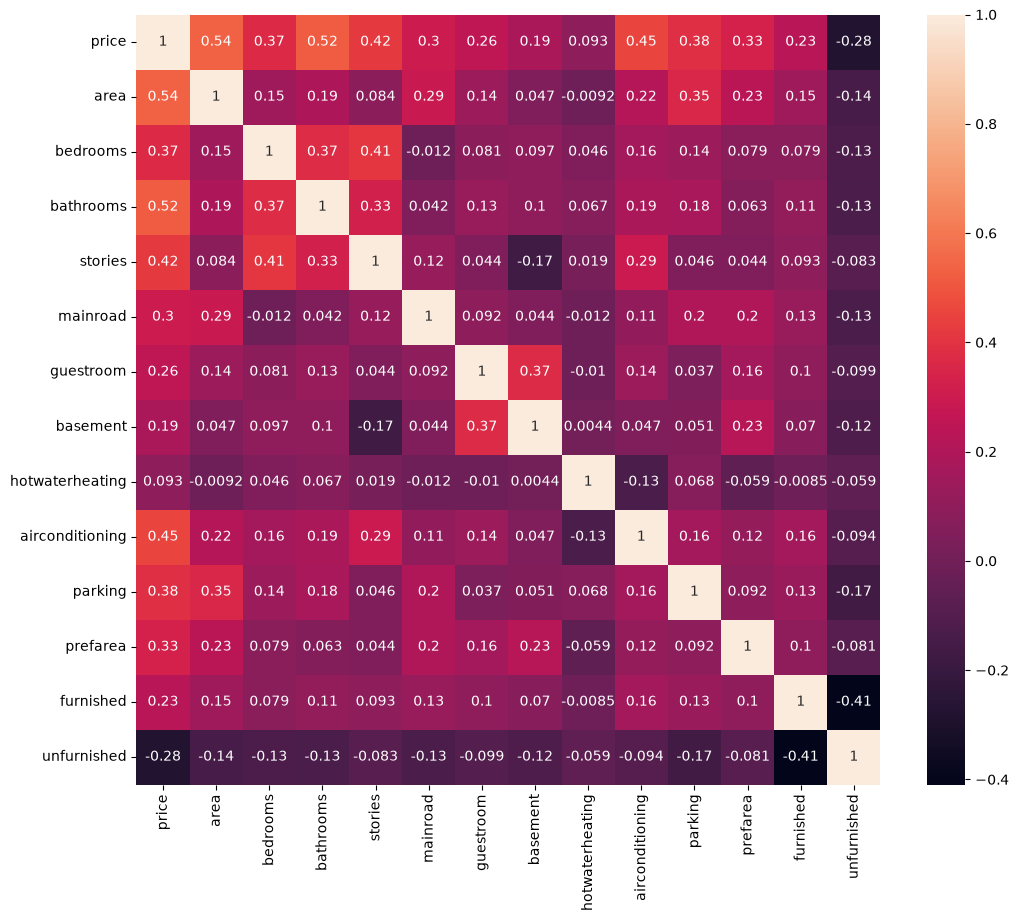

In [32]:
plt.figure(figsize=(12,10))
sns.heatmap(df_copy.corr(),annot=True)

In [6]:

#independent and dependent features
X = df_copy.drop('price',axis=1)
y = df_copy['price']

In [14]:
X.shape,y.shape

((545, 13), (545,))

In [17]:
type(X),type(y)

(pandas.DataFrame, pandas.Series)

In [18]:
from sklearn.model_selection import train_test_split


In [19]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
X_train.shape,X_test.shape

((436, 13), (109, 13))

In [ ]:
y_train.shape,y_test.shape

((436,), (109,))

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [23]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
X_train_scaled.shape,X_test_scaled.shape

((436, 13), (109, 13))

In [26]:
X_train_scaled,X_test_scaled

(array([[ 0.38416819,  0.05527092,  1.53917323, ..., -0.55262032,
          1.71111891, -0.67690027],
        [ 0.9291807 ,  0.05527092,  1.53917323, ..., -0.55262032,
         -0.58441292, -0.67690027],
        [-0.60775457, -1.28351359, -0.5579503 , ..., -0.55262032,
          1.71111891, -0.67690027],
        ...,
        [-0.29709744,  0.05527092,  1.53917323, ..., -0.55262032,
          1.71111891, -0.67690027],
        [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.55262032,
         -0.58441292,  1.47732249],
        [ 0.15707965,  0.05527092,  1.53917323, ..., -0.55262032,
         -0.58441292, -0.67690027]], shape=(436, 13)),
 array([[ 0.33875048,  1.39405543,  1.53917323, ..., -0.55262032,
         -0.58441292,  1.47732249],
        [ 0.61125674,  0.05527092,  1.53917323, ...,  1.80956067,
          1.71111891, -0.67690027],
        [-0.5060189 , -1.28351359, -0.5579503 , ..., -0.55262032,
         -0.58441292, -0.67690027],
        ...,
        [ 0.38416819,  1.39405543,  1

In [33]:
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression()

In [35]:
linear_regression_model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 519552.42, 57349.56, 521879.03,..., 266656.35, 55273.39,-133116.8 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.707e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[33.64,26.44,23.42,...,15.96,15.64,13.05]"


In [36]:
linear_regression_model.coef_,linear_regression_model.intercept_

(array([ 519552.41633999,   57349.55941862,  521879.02774805,
         349251.43890557,  128498.62821472,   88768.66768638,
         187067.80321388,  149862.70299085,  365157.39385091,
         192005.95366749,  266656.3519933 ,   55273.38625566,
        -133116.80155709]),
 np.float64(4706527.385321101))

In [37]:
y_train_pred = linear_regression_model.predict(X_train_scaled)
y_test_pred = linear_regression_model.predict(X_test_scaled)

In [38]:
print(y_test[:5].values)
print(y_test_pred[:5])


[4060000 6650000 3710000 6440000 2800000]
[5164653.90033967 7224722.29802166 3109863.24240338 4612075.3272256
 3294646.25725956]


In [39]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [40]:
train_score = r2_score(y_train,y_train_pred)
test_score = r2_score(y_test,y_test_pred)
print("Train R2 score : ",train_score)
print("Test R2 score : ",test_score)

Train R2 score :  0.6859438988560158
Test R2 score :  0.6529242642153176


In [41]:
mae = mean_absolute_error(y_test,y_test_pred)
mse = mean_squared_error(y_test,y_test_pred)
rmse = np.sqrt(mse)

In [42]:
print("Train R2 score : ",train_score)
print("Test R2 score : ",test_score)
print("MAE : ",mae)
print("MSE : ",mse)
print("RMSE : ",rmse)

Train R2 score :  0.6859438988560158
Test R2 score :  0.6529242642153176
MAE :  970043.4039201643
MSE :  1754318687330.668
RMSE :  1324506.9600914402


# Residuals analysis

Text(0.5, 1.0, 'Actual vs Predicted House Prices')

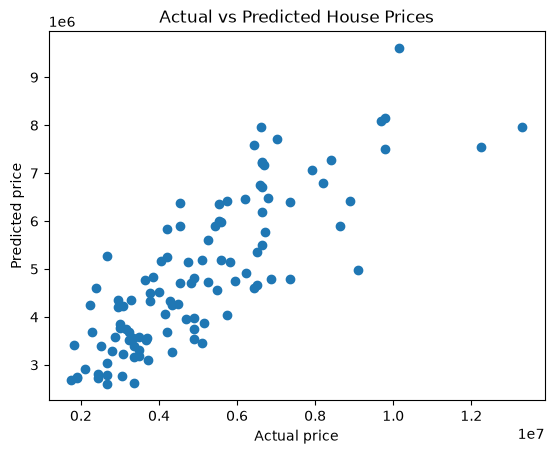

In [43]:
plt.scatter(y_test,y_test_pred)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted House Prices")

In [44]:
residuals = y_test - y_test_pred


Text(0.5, 1.0, 'residual plot')

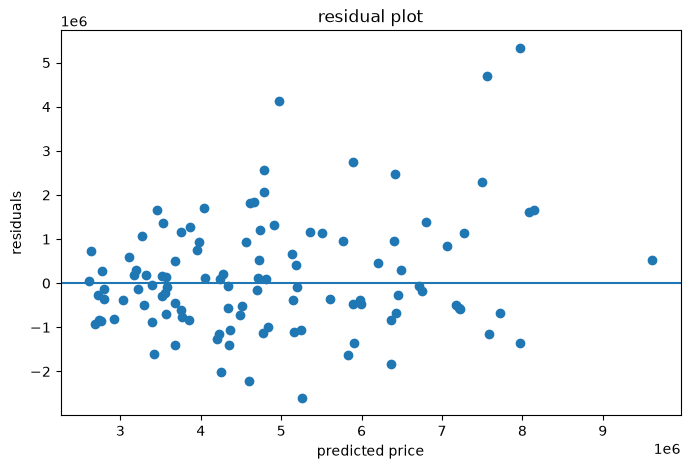

In [45]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_pred,residuals)
plt.axhline(y=0)
plt.xlabel("predicted price")
plt.ylabel("residuals")
plt.title("residual plot")


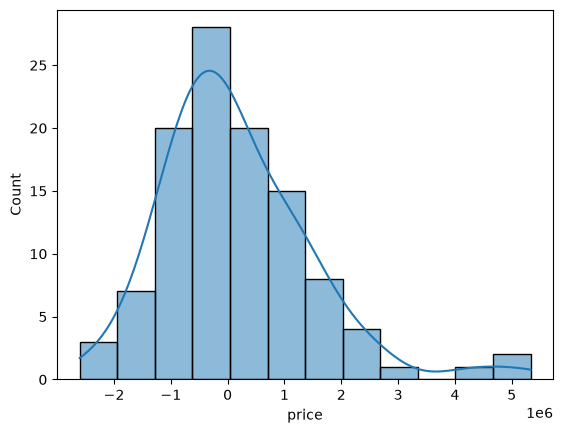

In [46]:
sns.histplot(residuals, kde=True)
plt.show()

Text(0.5, 1.0, 'Residuals vs Predicted Values')

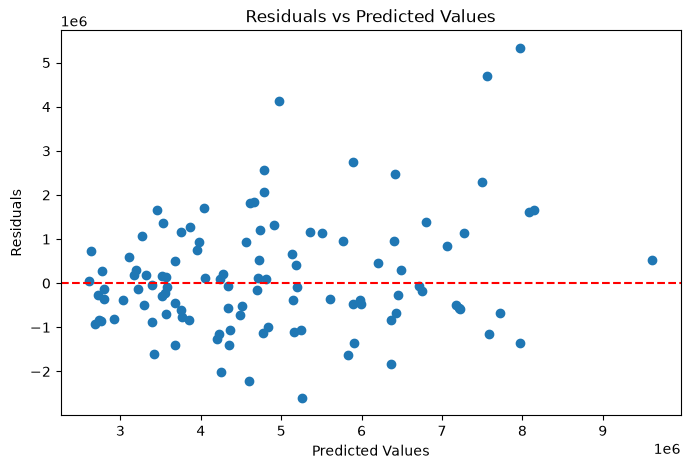

In [47]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_pred,residuals)
plt.axhline(y=0,color='red',linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")


In [48]:
print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())

Residual mean: 146055.36163152236
Residual std: 1322509.996233871


Text(0.5, 1.0, 'Actual vs Predicted')

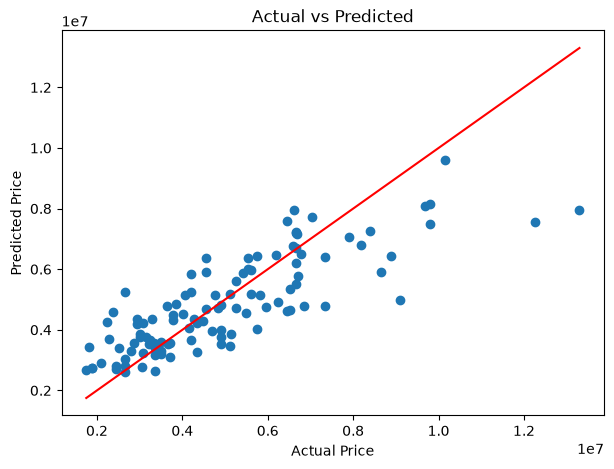

In [49]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

## Check if errors are concentrated in expensive houses

In [50]:
error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred,
    "Residual": residuals
})

error_df.sort_values(
    by="Residual",
    ascending=False
).head(10)

,Actual,Predicted,Residual
0,13300000,7.968276e+06,5.331724e+06
2,12250000,7.555324e+06,4.694676e+06
15,9100000,4.973331e+06,4.126669e+06
22,8645000,5.897889e+06,2.747111e+06
55,7350000,4.786123e+06,2.563877e+06
18,8890000,6.420308e+06,2.469692e+06
9,9800000,7.498029e+06,2.301971e+06
68,6860000,4.792291e+06,2.067709e+06
84,6510000,4.662381e+06,1.847619e+06
90,6440000,4.612075e+06,1.827925e+06


## Check feature importance/correlation

In [51]:
corr = df.corr()['price'].sort_values(ascending=False)

print(corr)

price              1.000000
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
bedrooms           0.366494
prefarea           0.329777
mainroad           0.296898
guestroom          0.255517
furnished          0.229350
basement           0.187057
hotwaterheating    0.093073
unfurnished       -0.280587
Name: price, dtype: float64


In [53]:
X_train.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnished', 'unfurnished'],
      dtype='str')

# Polynomial Regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)

In [55]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [56]:
scaler = StandardScaler()

In [57]:
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

In [58]:
polynomial_Model = LinearRegression()

In [59]:
polynomial_Model.fit(X_train_poly_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](105,)","[ 0. , 638580.99, -18774.16,...,-135360.94, 0. ,-182551.81]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.707e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,105
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,94
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](105,)","[92.43,70.2 ,63.89,..., 0. , 0. , 0. ]"


In [61]:
poly_train_score = polynomial_Model.score(X_train_poly_scaled,y_train)
poly_test_score = polynomial_Model.score(X_test_poly_scaled,y_test)

print("Train R2:", poly_train_score)
print("Test R2:", poly_test_score)

Train R2: 0.8013696211549626
Test R2: 0.6217587298299894


# Reject polynomial model because it is not performing that much

# Lasso Model

In [62]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

alphas = [0.01,0.1,1,10,100,1000,10000]

for alpha in alphas:
    lasso = Lasso(alpha=alpha,max_iter=10000)
    
    lasso.fit(X_train,y_train)
    
    train_score = lasso.score(X_train,y_train)
    test_score = lasso.score(X_test,y_test)
    
    print(
        "Alpha:", alpha,
        "Train R2:", train_score,
        "Test R2:", test_score
    )

Alpha: 0.01 Train R2: 0.6859438988560143 Test R2: 0.6529242574295513
Alpha: 0.1 Train R2: 0.6859438988558514 Test R2: 0.6529241963581311
Alpha: 1 Train R2: 0.6859438988395574 Test R2: 0.6529235854962616
Alpha: 10 Train R2: 0.6859438972110996 Test R2: 0.6529174774975933
Alpha: 100 Train R2: 0.6859437344008916 Test R2: 0.6528563271279246
Alpha: 1000 Train R2: 0.6859274485786881 Test R2: 0.6522369910102366
Alpha: 10000 Train R2: 0.684299066718626 Test R2: 0.6452646090766553


# not upto the mark similar performance to Linear regression model

# Ridge Regression

In [63]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

In [64]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

for alpha in alphas:
    
    ridge = Ridge(alpha=alpha)

    ridge.fit(X_train_scaled, y_train)

    train_pred = ridge.predict(X_train_scaled)
    test_pred = ridge.predict(X_test_scaled)

    print(
        "Alpha:", alpha,
        "Train R2:", r2_score(y_train, train_pred),
        "Test R2:", r2_score(y_test, test_pred)
    )

Alpha: 0.0001 Train R2: 0.6859438988560036 Test R2: 0.6529242513315932
Alpha: 0.001 Train R2: 0.6859438988547919 Test R2: 0.6529241353770505
Alpha: 0.01 Train R2: 0.6859438987336293 Test R2: 0.6529229757303177
Alpha: 0.1 Train R2: 0.6859438866235453 Test R2: 0.6529113691387027
Alpha: 1 Train R2: 0.6859426817679435 Test R2: 0.6527942971688783
Alpha: 10 Train R2: 0.6858280028834546 Test R2: 0.651528994869636
Alpha: 100 Train R2: 0.6780314660873343 Test R2: 0.6332260734413104


In [65]:
linear_regression_model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 244.14, 114787.56, 987668.11,..., 651543.8 , 46344.62,-364889.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea','furnished','unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3573
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


In [66]:
import pickle
with open('house_price_model.pkl','wb') as file:
    pickle.dump(linear_regression_model,file)

In [67]:
# load the model
with open('house_price_model.pkl','rb') as file:
    loaded_model = pickle.load(file)
    

In [68]:
prediction = loaded_model.predict([[5000,4,3,2,1,1,1,0,1,2,1,1,0]])
prediction

e:\Learn_AI_Engineering_BootCamp\AIEnv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([8729940.85995441])

In [69]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnished', 'unfurnished'],
      dtype='str')